# Level 5 — Basic Machine Learning

**Task:** Binary classification — predict whether an insurance claim gets flagged for manual review, based on claim details.

**Dataset:** Synthetic insurance claims (same style as Level 4), rebuilt here so this notebook is self-contained. The review flag is generated from an underlying "true" risk formula plus random noise — larger claims, certain claim types, and younger customers are more likely to be flagged, mirroring how a real underwriting rule might work, but with enough randomness that it's not perfectly predictable (like real life).

**What you'll practice:**
- Encoding categorical features (one-hot encoding)
- Train/test split
- Training a logistic regression classifier
- Evaluating with accuracy, precision, recall, and a confusion matrix
- Spotting and avoiding data leakage

You'll need `scikit-learn`:
```
pip install scikit-learn
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
np.random.seed(11)

## 1. Build the dataset (with a target that has real signal, not a trivial rule)

In [2]:
n = 400

claim_types = np.random.choice(["Motor", "Health", "Property", "Life"], size=n, p=[0.4, 0.3, 0.2, 0.1])
regions = np.random.choice(["Dar es Salaam", "Mbeya", "Arusha", "Dodoma", "Mwanza"], size=n)
age = np.random.randint(18, 75, size=n)
claim_amount = np.random.gamma(shape=2, scale=400000, size=n).round(0)

df = pd.DataFrame({
    "ClaimType": claim_types,
    "Region": regions,
    "CustomerAge": age,
    "ClaimAmount_TZS": claim_amount,
})

# Underlying "true" risk formula — this is what actually drives the review flag.
# Bigger claims, Motor/Property claims, and younger customers push risk up.
risk_score = (
    -3.5
    + 0.0000015 * df["ClaimAmount_TZS"]
    + df["ClaimType"].map({"Motor": 1.1, "Property": 0.9, "Health": 0.2, "Life": -0.3})
    + (35 - df["CustomerAge"]).clip(lower=0) * 0.02
    + np.random.normal(0, 0.8, n)  # noise — the part no model can ever fully capture
)

probability = 1 / (1 + np.exp(-risk_score))  # sigmoid: turns any real number into a 0-1 probability
df["FlaggedForReview"] = (np.random.rand(n) < probability).astype(int)

print("Review rate:", df["FlaggedForReview"].mean().round(3))
df.head()

Review rate: 0.262


,ClaimType,Region,CustomerAge,ClaimAmount_TZS,FlaggedForReview
0,Motor,Dodoma,35,501942.0,0
1,Motor,Dar es Salaam,30,153607.0,1
2,Health,Dodoma,23,84546.0,0
3,Property,Mwanza,65,1220437.0,0
4,Health,Arusha,63,593428.0,0


## 2. A note on data leakage — before we touch features

You hit this exact problem with the movie rating predictor and target encoding. Same principle here, worth restating explicitly:

**Leakage** happens when a feature secretly contains information about the target that wouldn't actually be available at prediction time — or that just mathematically encodes the answer. Two ways it could sneak in here:

- If we had a column like `ReviewNotes` that only exists *after* a human reviewed the claim, using it as a feature would be cheating — the model would be predicting the outcome using information that's only available once you already know the outcome.
- If we accidentally included something derived directly from `FlaggedForReview` itself (like a column that's literally `FlaggedForReview == 1` renamed), the model would get suspiciously perfect accuracy — a red flag, not a win.

The four features we're about to use — `ClaimType`, `Region`, `CustomerAge`, `ClaimAmount_TZS` — are all known at the moment the claim is filed, *before* any review happens. That's the test: **would you actually have this information at prediction time, in the real world?** If not, it doesn't belong in the feature set no matter how much it improves your metrics.

## 3. Encode categorical features

Models need numbers, not text. `ClaimType` and `Region` are categorical with no natural order, so one-hot encoding (a separate 0/1 column per category) is the right call here — not, say, assigning 1/2/3/4, which would falsely imply Motor < Health < Property < Life on some numeric scale.

In [3]:
df_encoded = pd.get_dummies(df, columns=["ClaimType", "Region"], drop_first=True)
df_encoded.head()

,CustomerAge,ClaimAmount_TZS,FlaggedForReview,ClaimType_Life,ClaimType_Motor,ClaimType_Property,Region_Dar es Salaam,Region_Dodoma,Region_Mbeya,Region_Mwanza
0,35,501942.0,0,False,True,False,False,True,False,False
1,30,153607.0,1,False,True,False,True,False,False,False
2,23,84546.0,0,False,False,False,False,True,False,False
3,65,1220437.0,0,False,False,True,False,False,False,True
4,63,593428.0,0,False,False,False,False,False,False,False


`drop_first=True` drops one category per column (e.g. `Region_Arusha` is gone). This isn't losing information — if a row is 0 across all the other Region columns, that *means* it's Arusha. Keeping all categories would create redundant, perfectly correlated columns, which causes problems for some models (not logistic regression specifically here, but it's a habit worth having).

## 4. Train/test split

Never evaluate a model on data it was trained on — that tells you how well it memorized, not how well it generalizes.

In [4]:
X = df_encoded.drop(columns=["FlaggedForReview"])
y = df_encoded["FlaggedForReview"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Train size:", len(X_train), " Test size:", len(X_test))
print("Review rate in train:", y_train.mean().round(3))
print("Review rate in test:", y_test.mean().round(3))

Train size: 300  Test size: 100
Review rate in train: 0.263
Review rate in test: 0.26


`stratify=y` keeps the same proportion of flagged/not-flagged claims in both the train and test sets. Without it, random splitting could accidentally dump most of the flagged claims into one side — especially risky here since review rate is well under 50%.

## 5. Train the model

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 6. Evaluate

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not Flagged", "Flagged"]))

Accuracy: 0.810

              precision    recall  f1-score   support

 Not Flagged       0.80      0.99      0.88        74
     Flagged       0.89      0.31      0.46        26

    accuracy                           0.81       100
   macro avg       0.85      0.65      0.67       100
weighted avg       0.82      0.81      0.77       100



**Reading the classification report:**
- **Precision** (for "Flagged"): of the claims the model predicted would be flagged, what fraction actually were? Low precision means lots of false alarms.
- **Recall** (for "Flagged"): of the claims that were actually flagged, what fraction did the model catch? Low recall means it's missing real cases.
- **These trade off against each other.** For something like review-flagging, missing a genuinely risky claim (low recall) is often worse than a few unnecessary manual reviews (lower precision) — which metric matters more depends entirely on the business cost of each type of mistake, not on which number looks better in isolation.

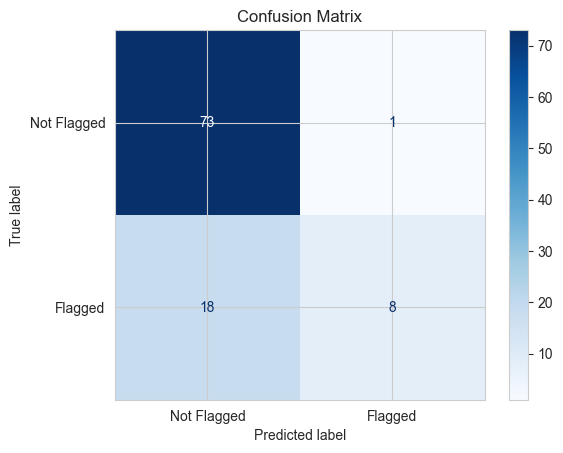

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Flagged", "Flagged"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

The confusion matrix breaks accuracy down into four buckets: correctly predicted "not flagged," correctly predicted "flagged," and the two ways to be wrong (false positive, false negative). A single accuracy number can hide a model that's great at one class and terrible at the other — this shows you which.

## 7. What's actually driving predictions?

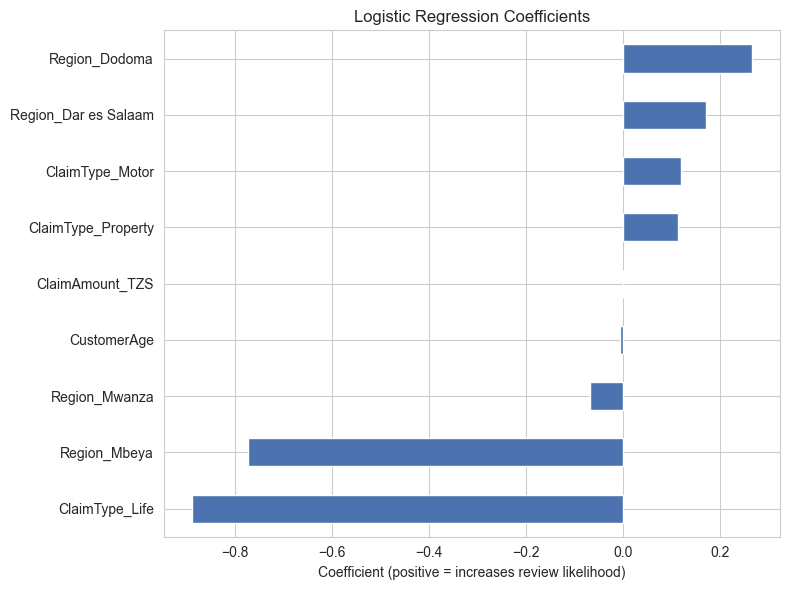

In [8]:
coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
coefficients.plot(kind="barh", color="#4C72B0")
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient (positive = increases review likelihood)")
plt.tight_layout()
plt.show()

Compare this chart against the risk formula in Section 1 — `ClaimAmount_TZS` and `ClaimType_Motor` should show up as strong positive drivers, which is exactly what we built into the data. This is a genuinely useful sanity check whenever you build a model on synthetic data: if the model can't recover the pattern you know you put in, something's wrong with either the model setup or the data — not a subtle bug to shrug off.

## Exercises

1. Change `test_size` to `0.5` and rerun from the train/test split cell onward. Does accuracy change much? What about with `test_size=0.1`? What's the trade-off you're making as you shrink the training set?
2. Add a new engineered feature — `HighAmount`, a binary flag for `ClaimAmount_TZS` above its median — and retrain. Does it improve the model, or is it redundant with the raw amount already being a feature?
3. Try `from sklearn.ensemble import RandomForestClassifier` instead of `LogisticRegression` (same `.fit()` / `.predict()` interface). Compare its accuracy and confusion matrix to logistic regression's — is it meaningfully better on a dataset this size?
4. (Challenge) Deliberately create a leaky feature: add a column `WasReviewedByHuman` that's just a slightly-noisy copy of `FlaggedForReview` (e.g. flip 5% of values at random), include it as a feature, and retrain. Watch what happens to accuracy. This is intentionally cheating — the point is to *see* what leakage looks like in the numbers, so you recognize the smell of "suspiciously good results" in a real project later.

In [9]:
# Your exercise answers here
for size in [0.5, 0.25, 0.1]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size, random_state=42, stratify=y)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"test_size={size}: train={len(X_train)}, test={len(X_test)}, accuracy={acc:.3f}")

test_size=0.5: train=200, test=200, accuracy=0.745
test_size=0.25: train=300, test=100, accuracy=0.810
test_size=0.1: train=360, test=40, accuracy=0.775


In [10]:
df["HighAmount"] = (df["ClaimAmount_TZS"] > df["ClaimAmount_TZS"].median()).astype(int)

df_encoded = pd.get_dummies(df, columns=["ClaimType", "Region"], drop_first=True)
X = df_encoded.drop(columns=["FlaggedForReview"])
y = df_encoded["FlaggedForReview"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy with HighAmount: {accuracy_score(y_test, y_pred):.3f}")

Accuracy with HighAmount: 0.790


Random Forest:
Accuracy: 0.770
              precision    recall  f1-score   support

 Not Flagged       0.80      0.92      0.86        74
     Flagged       0.60      0.35      0.44        26

    accuracy                           0.77       100
   macro avg       0.70      0.63      0.65       100
weighted avg       0.75      0.77      0.75       100



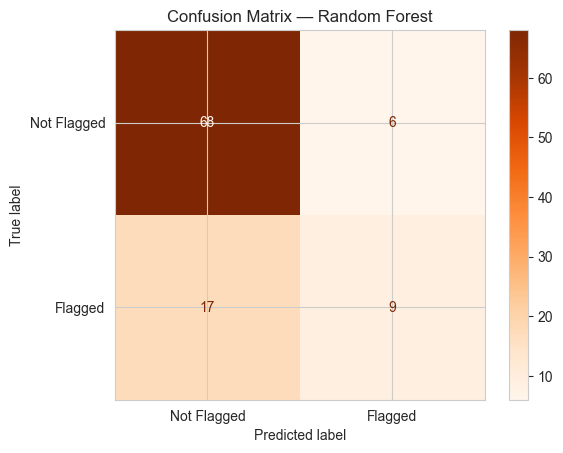

In [12]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf, target_names=["Not Flagged", "Flagged"]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Not Flagged", "Flagged"]).plot(cmap="Oranges")
plt.title("Confusion Matrix — Random Forest")
plt.show()

In [13]:
df["WasReviewedByHuman"] = df["FlaggedForReview"].copy()
flip_idx = df.sample(frac=0.05, random_state=99).index
df.loc[flip_idx, "WasReviewedByHuman"] = 1 - df.loc[flip_idx, "WasReviewedByHuman"]

df_encoded = pd.get_dummies(df, columns=["ClaimType", "Region"], drop_first=True)
X = df_encoded.drop(columns=["FlaggedForReview"])
y = df_encoded["FlaggedForReview"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy WITH leaky feature: {accuracy_score(y_test, y_pred):.3f}")

Accuracy WITH leaky feature: 0.960
